In [29]:
# ─── Temel veri işleme ve görselleştirme kütüphaneleri ───────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# ─── Scikit-learn araçları ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

# ─── Görsel Ayarlar ─────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Tüm kütüphaneler başarıyla yüklendi!')

✅ Tüm kütüphaneler başarıyla yüklendi!


In [30]:
print('🗂️ SPAM VERİ SETİ HAZIRLANIYOR...')
print('='*50)

# ─── Veri setini yükle ve temizle ───────────────────────────────────────────
df_spam = pd.read_csv("spam.csv", encoding="latin-1")
df_spam = df_spam[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
df_spam['label'] = df_spam['label'].map({'ham': 0, 'spam': 1})

# ─── Eğitim / Test bölmesi ──────────────────────────────────────────────────
X_train_raw_spam, X_test_raw_spam, y_train_spam, y_test_spam = train_test_split(
    df_spam['text'], df_spam['label'], test_size=0.2, random_state=42, stratify=df_spam['label']
)

# ─── TF-IDF Vektörleştirme (Metinler Sayıya Dönüşüyor) ──────────────────────
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_train_spam = vectorizer.fit_transform(X_train_raw_spam).toarray()
X_test_spam  = vectorizer.transform(X_test_raw_spam).toarray()

print(f'✅ Spam Verisi Bölündü: Eğitim={X_train_spam.shape[0]}, Test={X_test_spam.shape[0]}')

🗂️ SPAM VERİ SETİ HAZIRLANIYOR...
✅ Spam Verisi Bölündü: Eğitim=4457, Test=1115


In [31]:
print('🔵 SPAM İÇİN KNN EĞİTİLİYOR (K=5)...')
print('='*50)
knn_spam = KNeighborsClassifier(n_neighbors=5, metric='cosine')

start = time.time()
knn_spam.fit(X_train_spam, y_train_spam)
knn_train_time_spam = time.time() - start

start = time.time()
knn_pred_spam = knn_spam.predict(X_test_spam)
knn_pred_time_spam = time.time() - start
knn_prob_spam = knn_spam.predict_proba(X_test_spam)[:, 1]

print('🟠 SPAM İÇİN NAIVE BAYES (Multinomial) EĞİTİLİYOR...')
print('='*50)
nb_spam = MultinomialNB()

start = time.time()
nb_spam.fit(X_train_spam, y_train_spam)
nb_train_time_spam = time.time() - start

start = time.time()
nb_pred_spam = nb_spam.predict(X_test_spam)
nb_pred_time_spam = time.time() - start
nb_prob_spam = nb_spam.predict_proba(X_test_spam)[:, 1]

print('✅ Her iki model de Spam verisi üzerinde eğitildi ve test edildi.')

🔵 SPAM İÇİN KNN EĞİTİLİYOR (K=5)...
🟠 SPAM İÇİN NAIVE BAYES (Multinomial) EĞİTİLİYOR...
✅ Her iki model de Spam verisi üzerinde eğitildi ve test edildi.


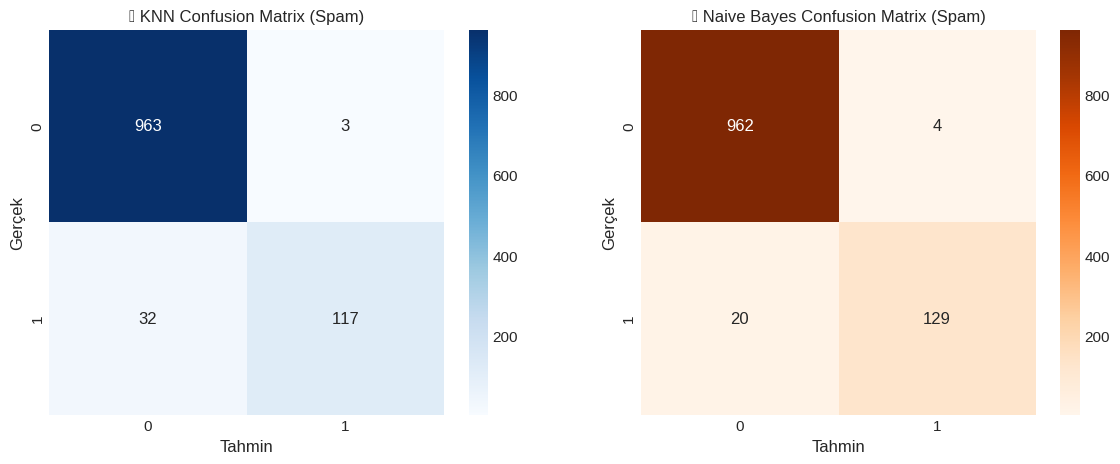

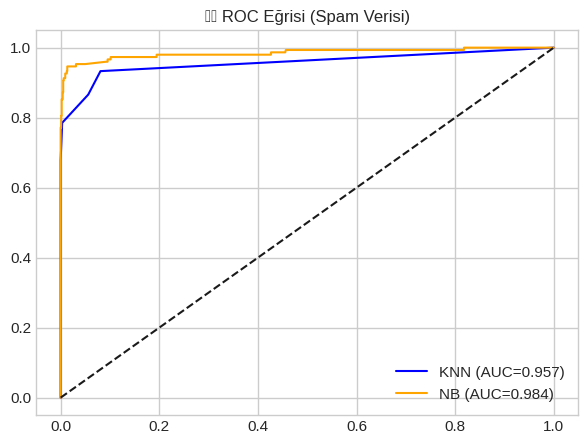


📋 SPAM VERİSİ - NİHAİ KARŞILAŞTIRMA
SPAM Verisi Metrikleri   KNN 🔵 Naive Bayes 🟠
              Accuracy  0.9686        0.9785
              F1 Score  0.8699        0.9149
    Eğitim Süresi (sn) 0.01502       0.10455
    Tahmin Süresi (sn) 0.73718       0.01259


In [32]:
# ─── Confusion Matrix Karşılaştırması ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test_spam, knn_pred_spam), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('🔵 KNN Confusion Matrix (Spam)')
axes[0].set_xlabel('Tahmin'); axes[0].set_ylabel('Gerçek')

sns.heatmap(confusion_matrix(y_test_spam, nb_pred_spam), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('🟠 Naive Bayes Confusion Matrix (Spam)')
axes[1].set_xlabel('Tahmin'); axes[1].set_ylabel('Gerçek')
plt.show()

# ─── ROC Eğrisi ────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
fpr_k, tpr_k, _ = roc_curve(y_test_spam, knn_prob_spam)
fpr_n, tpr_n, _ = roc_curve(y_test_spam, nb_prob_spam)
plt.plot(fpr_k, tpr_k, label=f'KNN (AUC={roc_auc_score(y_test_spam, knn_prob_spam):.3f})', color='blue')
plt.plot(fpr_n, tpr_n, label=f'NB (AUC={roc_auc_score(y_test_spam, nb_prob_spam):.3f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('⚖️ ROC Eğrisi (Spam Verisi)')
plt.legend()
plt.show()

# ─── Özet Tablo ────────────────────────────────────────────────────────────
res_spam = pd.DataFrame({
    'SPAM Verisi Metrikleri': ['Accuracy', 'F1 Score', 'Eğitim Süresi (sn)', 'Tahmin Süresi (sn)'],
    'KNN 🔵': [f'{accuracy_score(y_test_spam, knn_pred_spam):.4f}', f'{f1_score(y_test_spam, knn_pred_spam):.4f}', f'{knn_train_time_spam:.5f}', f'{knn_pred_time_spam:.5f}'],
    'Naive Bayes 🟠': [f'{accuracy_score(y_test_spam, nb_pred_spam):.4f}', f'{f1_score(y_test_spam, nb_pred_spam):.4f}', f'{nb_train_time_spam:.5f}', f'{nb_pred_time_spam:.5f}']
})
print('\n📋 SPAM VERİSİ - NİHAİ KARŞILAŞTIRMA')
print('='*55)
print(res_spam.to_string(index=False))

In [33]:
print('🗂️ ARAÇ DEĞERLENDİRME VERİ SETİ HAZIRLANIYOR...')
print('='*50)

# ─── Veriyi yükle ve kategorikleri sayısallaştır ───────────────────────────
df_car = pd.read_csv("car evaluation.csv")
df_car.columns = [col.strip() for col in df_car.columns]

X_car = df_car.drop(columns=['class'])
y_car = df_car['class']

encoder_car = OrdinalEncoder()
X_encoded_car = encoder_car.fit_transform(X_car)

label_encoder_car = LabelEncoder()
y_encoded_car = label_encoder_car.fit_transform(y_car)
class_names_car = label_encoder_car.classes_

# ─── Eğitim / Test bölmesi ──────────────────────────────────────────────────
X_train_c, X_test_c, y_train_car, y_test_car = train_test_split(
    X_encoded_car, y_encoded_car, test_size=0.2, random_state=42, stratify=y_encoded_car
)

# ─── KNN için Ölçeklendirme (Zorunlu) ───────────────────────────────────────
scaler_car = StandardScaler()
X_train_car = scaler_car.fit_transform(X_train_c)
X_test_car  = scaler_car.transform(X_test_c)

print(f'✅ Araç Verisi Bölündü: Eğitim={X_train_car.shape[0]}, Test={X_test_car.shape[0]}')

🗂️ ARAÇ DEĞERLENDİRME VERİ SETİ HAZIRLANIYOR...
✅ Araç Verisi Bölündü: Eğitim=1382, Test=346


In [34]:
print('🔵 ARAÇ VERİSİ İÇİN KNN EĞİTİLİYOR (K=5)...')
print('='*50)
knn_car = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

start = time.time()
knn_car.fit(X_train_car, y_train_car)
knn_train_time_car = time.time() - start

start = time.time()
knn_pred_car = knn_car.predict(X_test_car)
knn_pred_time_car = time.time() - start

print('🟠 ARAÇ VERİSİ İÇİN NAIVE BAYES (Gaussian) EĞİTİLİYOR...')
print('='*50)
nb_car = GaussianNB()

start = time.time()
nb_car.fit(X_train_car, y_train_car)
nb_train_time_car = time.time() - start

start = time.time()
nb_pred_car = nb_car.predict(X_test_car)
nb_pred_time_car = time.time() - start

print('✅ Her iki model de Araç verisi üzerinde eğitildi ve test edildi.')

🔵 ARAÇ VERİSİ İÇİN KNN EĞİTİLİYOR (K=5)...
🟠 ARAÇ VERİSİ İÇİN NAIVE BAYES (Gaussian) EĞİTİLİYOR...
✅ Her iki model de Araç verisi üzerinde eğitildi ve test edildi.


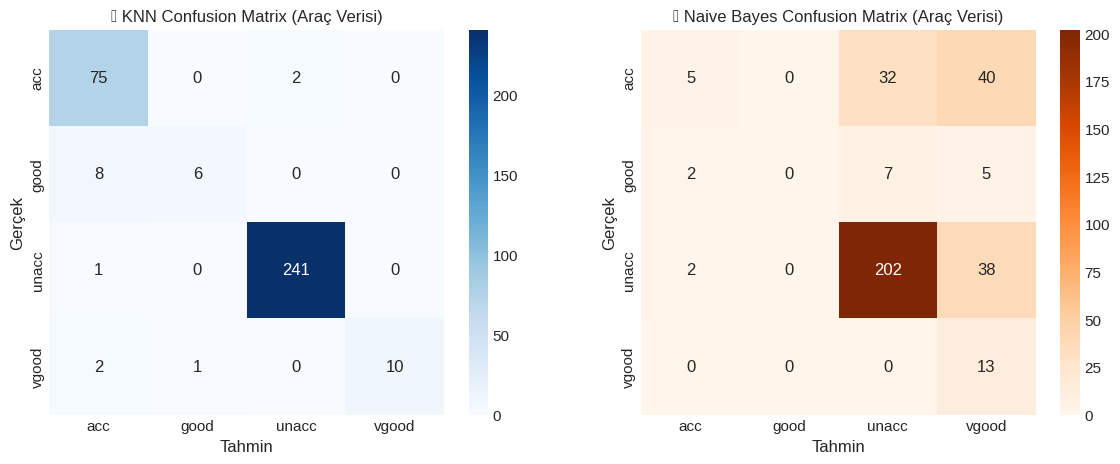


📋 ARAÇ VERİSİ - NİHAİ KARŞILAŞTIRMA
ARAÇ Verisi Metrikleri   KNN 🔵 Naive Bayes 🟠
              Accuracy  0.9595        0.6358
    Eğitim Süresi (sn) 0.00305       0.00281
    Tahmin Süresi (sn) 0.00766       0.00086


In [36]:
# ─── Confusion Matrix Karşılaştırması ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test_car, knn_pred_car), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_car, yticklabels=class_names_car, ax=axes[0])
axes[0].set_title('🔵 KNN Confusion Matrix (Araç Verisi)')
axes[0].set_xlabel('Tahmin'); axes[0].set_ylabel('Gerçek')

sns.heatmap(confusion_matrix(y_test_car, nb_pred_car), annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names_car, yticklabels=class_names_car, ax=axes[1])
axes[1].set_title('🟠 Naive Bayes Confusion Matrix (Araç Verisi)')
axes[1].set_xlabel('Tahmin'); axes[1].set_ylabel('Gerçek')
plt.show()

# ─── Özet Tablo ────────────────────────────────────────────────────────────
res_car = pd.DataFrame({
    'ARAÇ Verisi Metrikleri': ['Accuracy', 'Eğitim Süresi (sn)', 'Tahmin Süresi (sn)'],
    'KNN 🔵': [f'{accuracy_score(y_test_car, knn_pred_car):.4f}', f'{knn_train_time_car:.5f}', f'{knn_pred_time_car:.5f}'],
    'Naive Bayes 🟠': [f'{accuracy_score(y_test_car, nb_pred_car):.4f}', f'{nb_train_time_car:.5f}', f'{nb_pred_time_car:.5f}']
})
print('\n📋 ARAÇ VERİSİ - NİHAİ KARŞILAŞTIRMA')
print('='*55)
print(res_car.to_string(index=False))